In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("Food_Delivery_Times.csv")

In [3]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [5]:
df.shape

(1000, 9)

In [6]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [7]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [8]:
df=df.dropna()

In [9]:
df.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

In [10]:
df=df.drop("Courier_Experience_yrs",axis=1)

In [11]:
df=df.drop("Order_ID",axis=1)

In [12]:
df.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,43
1,16.42,Clear,Medium,Evening,Bike,20,84
2,9.52,Foggy,Low,Night,Scooter,28,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,37
4,19.03,Clear,Low,Morning,Bike,16,68


In [13]:
categories = [
    ['Clear', 'Windy', 'Foggy', 'Rainy', 'Snowy'], 
    ['Low', 'Medium', 'High'],                      
    ['Morning', 'Afternoon', 'Evening', 'Night']    
]

In [14]:
df=df.drop("Vehicle_Type",axis=1)

In [15]:
df.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Preparation_Time_min,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,12,43
1,16.42,Clear,Medium,Evening,20,84
2,9.52,Foggy,Low,Night,28,59
3,7.44,Rainy,Medium,Afternoon,5,37
4,19.03,Clear,Low,Morning,16,68


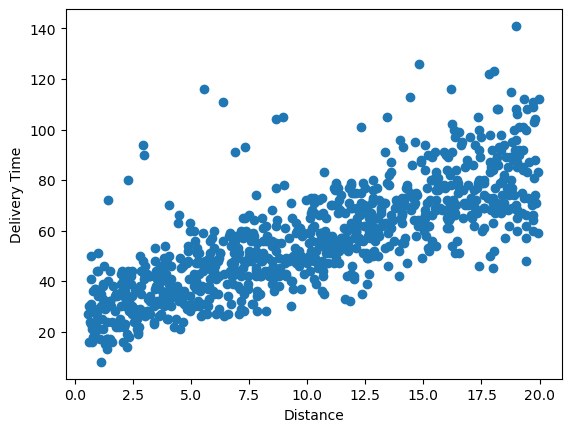

In [16]:
plt.scatter(df['Distance_km'], df['Delivery_Time_min'])
plt.xlabel("Distance")
plt.ylabel("Delivery Time")
plt.show()

In [17]:
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder(categories=categories)
df[["Weather","Traffic_Level","Time_of_Day"]] = encoder.fit_transform(df[["Weather","Traffic_Level","Time_of_Day"]])

In [18]:
df.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Preparation_Time_min,Delivery_Time_min
0,7.93,1.0,0.0,1.0,12,43
1,16.42,0.0,1.0,2.0,20,84
2,9.52,2.0,0.0,3.0,28,59
3,7.44,3.0,1.0,1.0,5,37
4,19.03,0.0,0.0,0.0,16,68


In [19]:
x=df.drop("Delivery_Time_min",axis=1)
y=df["Delivery_Time_min"]

In [20]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2)

In [21]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [22]:
y_pred=model.predict(x_test)

In [23]:
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(y_test,y_pred)

In [24]:
print("mse: ",mse)

mse:  84.80159858829721


In [25]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R2:", r2)

R2: 0.8190970338665177


In [26]:
print(x_train.shape)
print(y_train.shape)

(706, 5)
(706,)


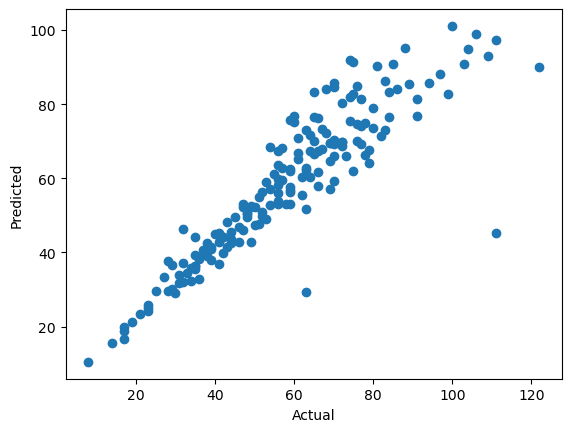

In [27]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [28]:
print("Train R2:", model.score(x_train, y_train))
print("Test R2:", model.score(x_test, y_test))

Train R2: 0.7644004067785404
Test R2: 0.8190970338665177


In [29]:
import pickle
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)
print("Saved!")

Saved!


In [30]:
import pickle
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)

In [31]:
import os
print(os.getcwd())

C:\Users\harin\Projects\Linear_Regression
